## Zomato Data Analysis Using Python

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

* Do more restaurants provide online delivery compared to offline services?
* Which types of restaurants are most favored by the general public?
* What price range do couples prefer for dining out?

## Implementation for Zomato Data Analysis using Python.
* Step 1: Importing necessary Python libraries.  
* We will be using Pandas, Numpy, Matplotlib and Seaborn libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

## Now we have to create or read our csv file 

In [3]:
data=pd.read_csv("Zomato.csv")
df=pd.DataFrame(data)
print(df.to_string()) # to_string gives the entire rows of the dataFrame or our dataset

                                                name online_order book_table    rate  votes  approx_cost(for two people) listed_in(type)
0                                              Jalsa          Yes        Yes   4.1/5    775                          800          Buffet
1                                     Spice Elephant          Yes         No   4.1/5    787                          800          Buffet
2                                    San Churro Cafe          Yes         No   3.8/5    918                          800          Buffet
3                              Addhuri Udupi Bhojana           No         No   3.7/5     88                          300          Buffet
4                                      Grand Village           No         No   3.8/5    166                          600          Buffet
5                                    Timepass Dinner          Yes         No   3.8/5    286                          600          Buffet
6    Rosewood International Hotel - Bar &

## Understanding the data 

In [4]:
print(df.head(5)) #  printing the first 10 rows with all columns 

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
print(df.tail(5)) # printing the tail of 5 columns 

                 name online_order book_table   rate  votes  \
143  Melting Melodies           No         No  3.3/5      0   
144   New Indraprasta           No         No  3.3/5      0   
145      Anna Kuteera          Yes         No  4.0/5    771   
146            Darbar           No         No  3.0/5     98   
147     Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
143                          100          Dining  
144                          150          Dining  
145                          450          Dining  
146                          800          Dining  
147                          200          Dining  


In [6]:
df.shape # checking the shape it is like 148 rows and 7 columns 

(148, 7)

In [7]:
print(df.size) # the size of our dataset is 1036
print(df.index) # Checking the index range
print(df.dtypes) # checking the data types 
print(df.describe()) # here we see the describe function is only act on the int data type columns 

1036
RangeIndex(start=0, stop=148, step=1)
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object
             votes  approx_cost(for two people)
count   148.000000                   148.000000
mean    264.810811                   418.243243
std     653.676951                   223.085098
min       0.000000                   100.000000
25%       6.750000                   200.000000
50%      43.500000                   400.000000
75%     221.750000                   600.000000
max    4884.000000                   950.000000


In [8]:
print(df.info()) # checking the information of the data set 
print(df.nunique()) # checking the nunique ness of the dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None
name                           145
online_order                     2
book_table                       2
rate                            20
votes                           90
approx_cost(for two people)     18
listed_in(type)                  4
dtype: int64


* In our data undestanding we noticed one thing that one is our rating column contains object datatype we want to convert that object data type in to float

## Data Cleaning and Preparation
1. Convert the rate column to a float by removing denominator characters.

In [9]:
def handlerate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)
df["rate"]=df["rate"].apply(handlerate)
print(df)
print(df.dtypes)

                      name online_order book_table  rate  votes  \
0                    Jalsa          Yes        Yes   4.1    775   
1           Spice Elephant          Yes         No   4.1    787   
2          San Churro Cafe          Yes         No   3.8    918   
3    Addhuri Udupi Bhojana           No         No   3.7     88   
4            Grand Village           No         No   3.8    166   
..                     ...          ...        ...   ...    ...   
143       Melting Melodies           No         No   3.3      0   
144        New Indraprasta           No         No   3.3      0   
145           Anna Kuteera          Yes         No   4.0    771   
146                 Darbar           No         No   3.0     98   
147          Vijayalakshmi          Yes         No   3.9     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            800          

In [10]:
#3. Checking for missing or null values to identify any data gaps.
print(df.isnull().sum())
print(df.isna().sum())
#There is no NULL value in dataframe.


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


## visualisation of Data 

Text(0.5, 1.0, 'Type of resturant')

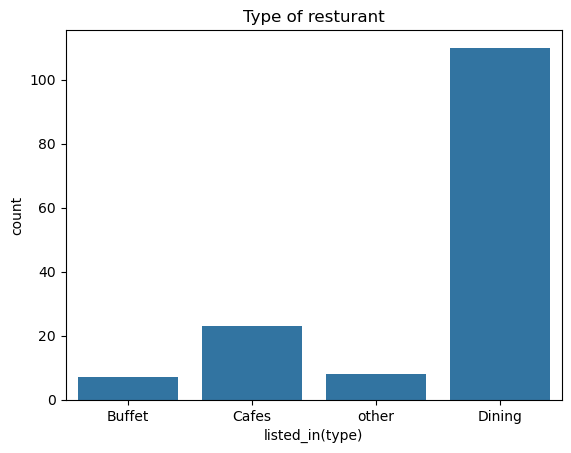

In [11]:
#Step 4: Exploring Restaurant Types
sns.countplot(x=df["listed_in(type)"])
plt.title("Type of resturant")
# Conclusion: The majority of the restaurants fall into the dining category.

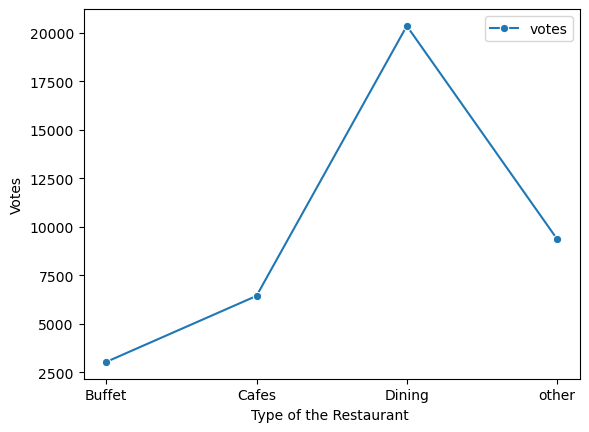

In [20]:
#2. Votes by Restaurant Type
# Here we get the count of votes for each category.

data1=df.groupby('listed_in(type)')["votes"].sum()
result=pd.DataFrame({"votes":data1})
sns.lineplot(result,c="red",marker="o")
plt.xlabel("Type of the Restaurant ")
plt.ylabel("Votes")
plt.show()
# Conclusion: Dining restaurants are preferred by a larger number of individuals.

In [24]:
# Step 5: Identify the Most Voted Restaurant
# Find the restaurant with the highest number of votes.
max_votes=df["votes"].max()
restauranr_with_max_votes=df.loc[df["votes"]==max_votes]
print("restaurant(s) with the maximum votes")
print(restauranr_with_max_votes)


restaurant(s) with the maximum votes
                 name online_order book_table  rate  votes  \
38  Empire Restaurant          Yes         No   4.4   4884   

    approx_cost(for two people) listed_in(type)  
38                          750           other  


<Axes: xlabel='online_order', ylabel='count'>

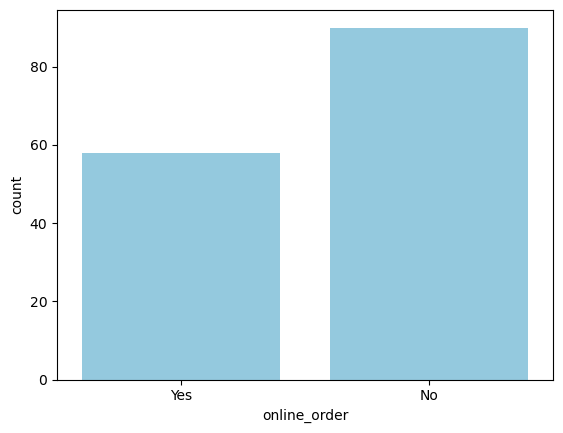

In [27]:
# Step 6: Online Order Availability
# Exploring the online_order column to see how many restaurants accept online
sns.countplot(x=df["online_order"],color="skyblue")
# Conclusion: This suggests that a majority of the restaurants do not accept online orders.

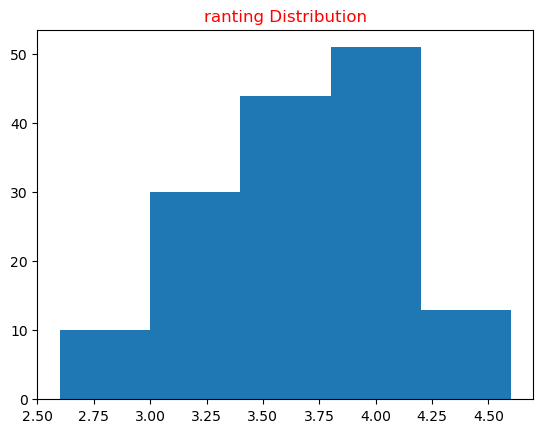

In [ ]:
# Step 7: Analyze Ratings
#Checking the distribution of ratings from the rate column.
plt.hist(df["rate"],bins=5)
plt.title("ranting Distribution",color="red")
plt.show()
# Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

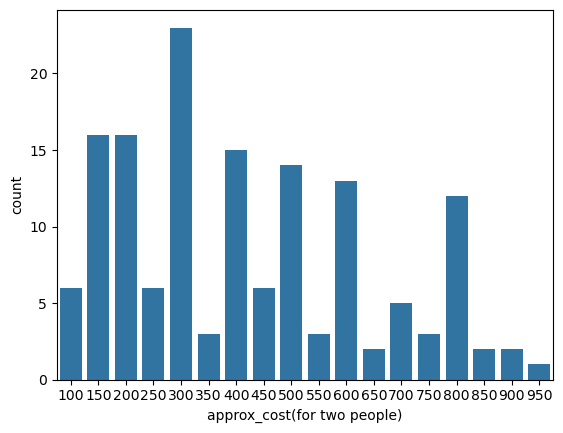

In [ ]:
# Step 8: Approximate Cost for Couples 
# Analyze the approx_cost(for two people) column to find the preferred price range
couple_data=df["approx_cost(for two people)"]
sns.countplot(x=couple_data)
# Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

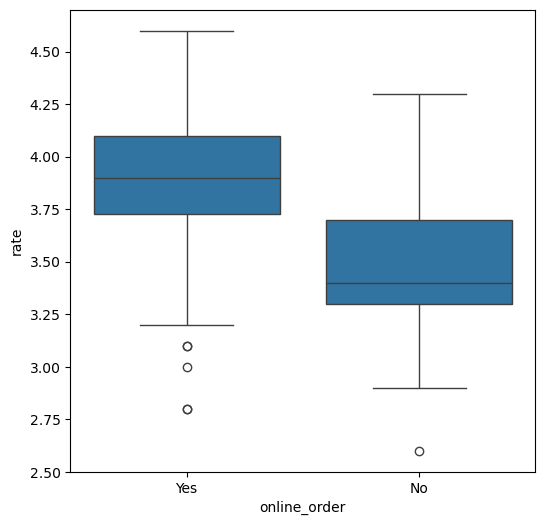

In [ ]:
# Step 9: Ratings Comparison - Online vs Offline Orders
#  Compare ratings between restaurants that accept online orders and those that don't.
plt.figure(figsize=(6,6))
sns.boxplot(x="online_order",y="rate",data=df)
plt.show()
# Conclusion: Offline orders received lower ratings in comparison to online orders which obtained excellent ratings.

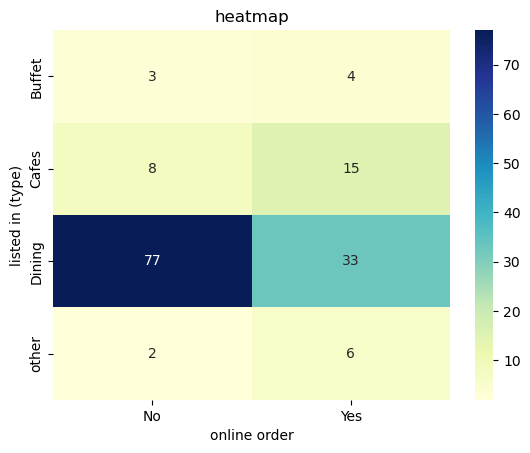

In [35]:
#Step 10: Order Mode Preferences by Restaurant Type
# Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).
pivot_table=df.pivot_table(index="listed_in(type)",columns="online_order",aggfunc="size",fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap="YlGnBu",fmt="d")
plt.title("heatmap")
plt.xlabel("online order")
plt.ylabel("listed in (type)")
plt.show()



## With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.